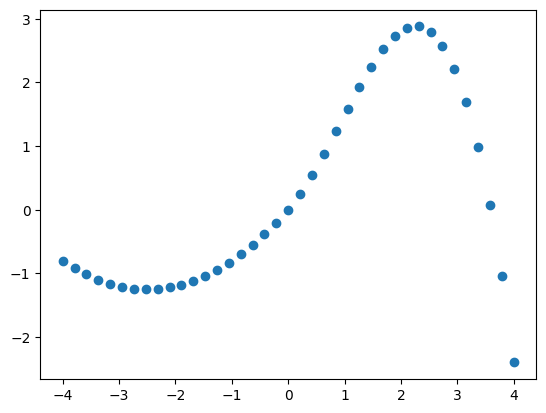

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def quadratic(x, a=0.2, b=1, c=0):
    return a*x**2 + b*x + c

# Define the cubic function (for x > 0)
def cubic(x, d=-0.3, e=0.8, f=1, g=0):
    return d*x**3 + e*x**2 + f*x + g

quad=np.linspace(-4,0,20)
cube=np.linspace(0,4,20)

yquad=[quadratic(x) for x in quad]
ycube=[cubic(x) for x in cube]

xvals=np.concatenate((quad,cube[1:]))
yvals=np.concatenate((yquad,ycube[1:]))

plt.plot(xvals,yvals,"o")



## SciPy CubicSpline

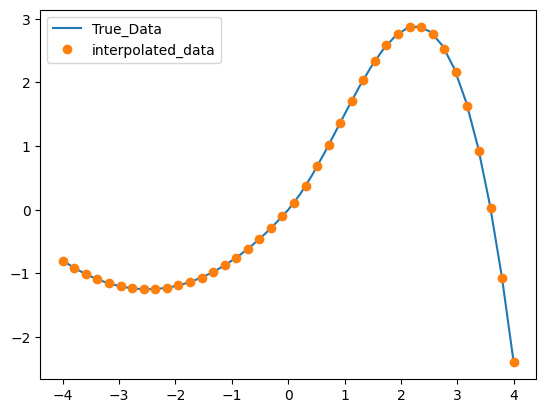

In [24]:
from scipy.interpolate import CubicSpline

spline = CubicSpline(xvals, yvals)
print(spline)
x_spline = np.linspace(min(xvals), max(xvals), 40)
y_spline = spline(x_spline)

plt.plot(xvals,yvals, label="True_Data")
plt.plot(x_spline,y_spline, 'o', label="interpolated_data")
plt.legend()


## Bézier Least-squares fit 

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
[-4.  -0.8] [-1.33331824 -6.84602272] [ 1.33333969 10.32870525] [ 4.  -2.4]


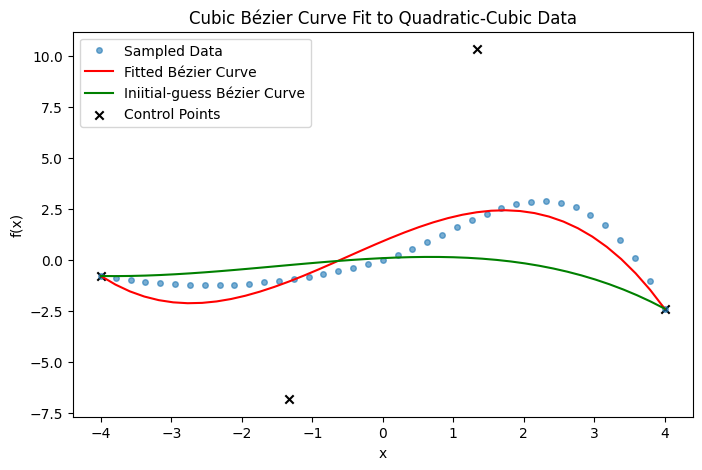

In [25]:
from scipy.optimize import least_squares

# Parameterize t values (normalized between 0 and 1)
t_vals = np.linspace(0, 1, len(xvals))


def bezier_curve(t, P0, P1, P2, P3):
    return (1 - t) ** 3 * P0 + 3 * (1 - t) ** 2 * t * P1 + 3 * (1 - t) * t ** 2 * P2 + t ** 3 * P3

# Define residuals for least squares fitting
def bezier_residuals(control_pts, t_vals, x_data, y_data):
    P0, P3 = np.array([x_data[0], y_data[0]]), np.array([x_data[-1], y_data[-1]])
    P1, P2 = control_pts[:2], control_pts[2:]
    
    bezier_points = np.array([bezier_curve(t, P0, P1, P2, P3) for t in t_vals])
    return (bezier_points[:, 0] - x_data)**2 + (bezier_points[:, 1] - y_data)**2

# Initial guess for control points (midpoints for P1 and P2)
initial_guess = [xvals[len(xvals)//3], yvals[len(xvals)//3], 
                 xvals[2*len(xvals)//3], yvals[2*len(xvals)//3]]

# Optimize P1 and P2 using least squares
result_lm = least_squares(bezier_residuals, initial_guess, method="lm",args=(t_vals, xvals, yvals))
result_trf = least_squares(bezier_residuals, initial_guess, method="trf",args=(t_vals, xvals, yvals))
result_dog = least_squares(bezier_residuals, initial_guess, method="dogbox",args=(t_vals, xvals, yvals))
P1_opt_lm, P2_opt_lm = result_lm.x[:2], result_lm.x[2:]
P1_opt_trf, P2_opt_trf = result_trf.x[:2], result_trf.x[2:]
P1_opt_dog, P2_opt_dog = result_dog.x[:2], result_dog.x[2:]

P1_initial,P2_initial=np.array(initial_guess[:2]), np.array(initial_guess[2:])

print(type(P1_opt_trf), type(P1_initial))
# Compute Bézier curve points using optimized control points
P0, P3 = np.array([xvals[0], yvals[0]]), np.array([xvals[-1], yvals[-1]])
t_fine = np.linspace(0, 1, 40)
bezier_points_lm = np.array([bezier_curve(t, P0, P1_opt_lm, P2_opt_lm, P3) for t in t_fine])
#bezier_points_trf = np.array([bezier_curve(t, P0, P1_opt_trf, P2_opt_trf, P3) for t in t_fine])
#bezier_points_dog = np.array([bezier_curve(t, P0, P1_opt_dog, P2_opt_dog, P3) for t in t_fine])
bezier_points_initial=np.array([bezier_curve(t,P0, P1_initial, P2_initial, P3) for t in t_fine])
# Plot original data and fitted Bézier curve
plt.figure(figsize=(8, 5))
plt.plot(xvals, yvals, 'o', label="Sampled Data", markersize=4, alpha=0.6)
plt.plot(bezier_points_lm[:, 0], bezier_points_lm[:, 1], label="Fitted Bézier Curve", color='r')
#plt.plot(bezier_points_trf[:, 0], bezier_points_trf[:, 1], label="Fitted Bézier Curve", )
#plt.plot(bezier_points_dog[:, 0], bezier_points_dog[:, 1], label="Fitted Bézier Curve", )
plt.plot(bezier_points_initial[:, 0], bezier_points_initial[:, 1], label="Iniitial-guess Bézier Curve", color='g')
print(P0,P1_opt_lm,P2_opt_lm,P3)
plt.scatter([P0[0], P1_opt_lm[0], P2_opt_lm[0], P3[0]], 
            [P0[1], P1_opt_lm[1], P2_opt_lm[1], P3[1]], 
            color='black', marker='x', label="Control Points")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Cubic Bézier Curve Fit to Quadratic-Cubic Data")
plt.show()

## Bézier CVX approx fit

[[   1.   -8.   28.  -56.   70.  -56.   28.   -8.    1.]
 [  -0.    8.  -56.  168. -280.  280. -168.   56.   -8.]
 [   0.   -0.   28. -168.  420. -560.  420. -168.   28.]
 [  -0.    0.   -0.   56. -280.  560. -560.  280.  -56.]
 [   0.   -0.    0.   -0.   70. -280.  420. -280.   70.]
 [  -0.    0.   -0.    0.   -0.   56. -168.  168.  -56.]
 [   0.   -0.    0.   -0.    0.   -0.   28.  -56.   28.]
 [  -0.    0.   -0.    0.   -0.    0.   -0.    8.   -8.]
 [   0.   -0.    0.   -0.    0.   -0.    0.   -0.    1.]]
[[-4.         -0.8       ]
 [-3.15789474 -1.1634349 ]
 [-2.10526316 -1.21883657]
 [-1.05263158 -0.83102493]
 [ 0.          0.        ]
 [ 1.05263158  1.58915294]
 [ 2.10526316  2.85172766]
 [ 3.15789474  1.68829275]
 [ 4.         -2.4       ]]
(9, 2)


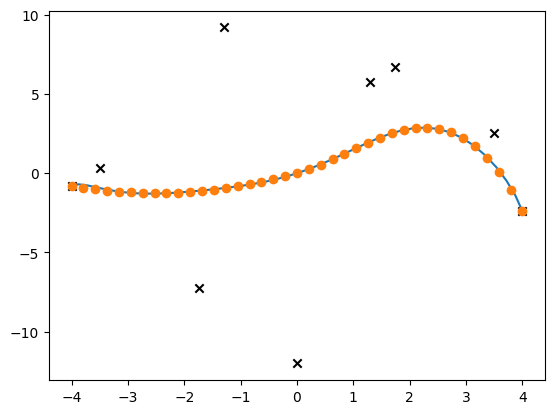

In [49]:
import cvxpy as cp
from math import comb
import numpy as np


def bezier_curveN(n, t, control_points):
    """
    Compute the Bézier curve at parameter t.
    
    Parameters:
    n (int): Degree of the Bézier curve.
    t (float): Parameter in range (0,1).
    control_points (np.ndarray): n x 2 array of control points.
    
    Returns:
    np.ndarray: (x, y) point on the Bézier curve.
    """
    if not (0 <= t <= 1):
        raise ValueError("t must be in the range (0,1)")
    
    if control_points.shape != (n + 1, 2):
        raise ValueError("control_points must be an (n+1) x 2 array")
    
    point = np.zeros(2)
    for i in range(n + 1):
        bernstein = comb(n, i) * (1 - t) ** (n - i) * t ** i
        point += bernstein * control_points[i]
    
    return point
#t_range=np.linspace()

n=8

Bpatch=np.zeros([n+1,n+1])
for i in range(n+1):
    for j in range(n+1):
        Bpatch[i, j]=(-1)**(j-i)*comb(n,j)*comb(j,i)

print(Bpatch)

Pix=cp.Variable([n+1])
Piy=cp.Variable([n+1])
projection=[i/n for i in range(n+1)]
cost=0

initial_guess = [[xvals[0], yvals[0]],
                 [xvals[len(xvals)//n], yvals[len(xvals)//n]], 
                 [xvals[2*len(xvals)//n], yvals[2*len(xvals)//n]],
                 [xvals[3*len(xvals)//n], yvals[3*len(xvals)//n]],
                 [xvals[-1], yvals[-1]]]

control_points=np.zeros([n+1,2])
for i in range(n+1):
    if i==n:
        control_points[i]=[xvals[-1],yvals[-1]]
    else:
        control_points[i]=[xvals[i*len(xvals)//n],yvals[i*len(xvals)//n]]

print(control_points)
Kx=Bpatch.T@Pix
Ky=Bpatch.T@Piy

for i in range(n+1):
    v=projection[i]
    V=np.array([v**i for i in range(n+1)])
    rsx=V@Kx
    rsy=V@Ky

    cost+=cp.square(cp.norm(cp.hstack([rsx-control_points[i][0], rsy-control_points[i][1]])))

prob=cp.Problem(cp.Minimize(cost))
prob.solve()

Pi=np.dstack([Pix.value, Piy.value])[0]

print(np.shape(Pi))
bezier_points = np.array([bezier_curveN(n,t, Pi) for t in t_fine])

plt.plot(bezier_points[:,0],bezier_points[:,1])
plt.scatter([Pi[:,0]],[Pi[:,1]],color='black', marker='x', label="Control Points")
plt.plot(xvals,yvals,'o')

